# Entrenamiento y optimización

- Objetivo: Entrenar distintos modelos de clasificación para predecir la variable objetivo `smoking`.

- La métrica principal de evaluación será F1-Score para la clase positiva (fumadores).-

# Importación de Librerías

In [30]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# PATHS

In [31]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Verificación PATHS

In [32]:
print(BASE_DIR)
print(RAW_DIR)
print(PROCESSED_DIR)

c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2
c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\data\raw
c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\data\processed


# Carga de datasets

In [33]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

test_fe = pd.read_csv(PROCESSED_DIR / "test_fe.csv")

# Verificación de dimensiones

In [34]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("test_fe:", test_fe.shape)

X_train: (40000, 24)
X_test : (10000, 24)
y_train: (40000,)
y_test : (10000,)
test_fe: (5692, 24)


# Verificación de la distribución de la target

In [35]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

smoking
0    0.633425
1    0.366575
Name: proportion, dtype: float64
smoking
0    0.6334
1    0.3666
Name: proportion, dtype: float64


# Primer Modelo Logistic Regression

In [36]:
lr = LogisticRegression(
    random_state=42,
    max_iter=3000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

c:\Users\sdecicco\DataReliabilityLab\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


- Se observó una advertencia de convergencia asociada a la diferencia de escalas entre las variables. Dado que el objetivo principal era comparar distintos enfoques de clasificación, se continuó con la evaluación y posteriormente se consideró un modelo basado en árboles (Random Forest), menos sensible a este problema.

# Métricas Logistic Regression

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.7396
Precision: 0.6319582504970179
Recall   : 0.6936715766503001
F1 Score : 0.6613784135240572


In [38]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      6334
           1       0.63      0.69      0.66      3666

    accuracy                           0.74     10000
   macro avg       0.72      0.73      0.72     10000
weighted avg       0.75      0.74      0.74     10000



# Predicciones sobre TRAIN

In [39]:
y_pred_lr_train = lr.predict(X_train)

print("=== LOGISTIC REGRESSION - TRAIN ===")
print(classification_report(y_train, y_pred_lr_train))

print("=== LOGISTIC REGRESSION - TEST ===")
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION - TRAIN ===
              precision    recall  f1-score   support

           0       0.81      0.78      0.79     25337
           1       0.64      0.69      0.67     14663

    accuracy                           0.75     40000
   macro avg       0.73      0.73      0.73     40000
weighted avg       0.75      0.75      0.75     40000

=== LOGISTIC REGRESSION - TEST ===
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      6334
           1       0.63      0.69      0.66      3666

    accuracy                           0.74     10000
   macro avg       0.72      0.73      0.72     10000
weighted avg       0.75      0.74      0.74     10000



# La regresión logística presentó advertencias de convergencia aun aumentando el número máximo de iteraciones (de 1000 a 3000). Sin embargo, el modelo entrenó correctamente y fue utilizado únicamente como baseline de comparación frente a Random Forest y XGBoost, que obtuvieron mejores resultados de F1 Score.

# Aunque la regresión logística mostró una generalización más estable entre entrenamiento y prueba, Random Forest obtuvo un F1 Score significativamente superior e una primer instancia del TP2 sobre el conjunto de test, que fue la métrica principal utilizada para comparar modelos.

# Segundo Modelo Random Forest

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Métricas Random Forest

In [41]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7977
Precision: 0.7106950500128238
Recall   : 0.7558647026732133
F1 Score : 0.7325842696629213


In [42]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      6334
           1       0.71      0.76      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.78     10000
weighted avg       0.80      0.80      0.80     10000



- El modelo Random Forest obtuvo un F1-Score de 0.73 sobre el conjunto de prueba, superando el desempeño observado en la Regresión Logística (F1 = 0.66).

- Por este motivo se selecciona Random Forest como modelo principal para las siguientes etapas del proyecto.

# Predicciones sobre TRAIN

In [43]:
y_pred_rf_train = rf.predict(X_train)

In [44]:
print("=== RANDOM FOREST - TRAIN ===")
print(classification_report(y_train, y_pred_rf_train))

print("=== RANDOM FOREST - TEST ===")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25337
           1       0.99      0.99      0.99     14663

    accuracy                           0.99     40000
   macro avg       0.99      0.99      0.99     40000
weighted avg       0.99      0.99      0.99     40000

=== RANDOM FOREST - TEST ===
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      6334
           1       0.71      0.76      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.78     10000
weighted avg       0.80      0.80      0.80     10000



# En una primer instancia del TP2:

- El modelo Random Forest obtuvo un desempeño perfecto sobre el conjunto de entrenamiento (F1 = 1.00), mientras que sobre el conjunto de prueba alcanzó un F1-Score de 0.73.

- Esto indica la presencia fuerte de sobreajuste (Overfitting), entendiendo  este comportamiento como habitual en modelos basados en árboles cuando se utilizan con parámetros por defecto.

- Aun así, el desempeño sobre el conjunto de prueba fue superior al obtenido por la Regresión Logística (F1 = 0.66), por lo que se seleccionó Random Forest como modelo principal.

# En una segunda instancia del TP2: 
 
- Se evaluaron distintas configuraciones del algoritmo Random Forest modificando la cantidad de árboles y la profundidad máxima. Los resultados muestran que incrementar la cantidad de árboles de 100 a 200 no produjo mejoras significativas en el F1 Score. Asimismo, limitar la profundidad máxima a 10 niveles redujo el rendimiento del modelo. La mejor configuración resultó ser la configuración base con 100 árboles, obteniendo un F1 Score aproximado de 0.73 sobre el conjunto de prueba.

# Pruebas Random Forest

# Prueba 1
- n_estimators = 100
=== RANDOM FOREST - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25337
           1       1.00      1.00      1.00     14663

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

=== RANDOM FOREST - TEST ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6334
           1       0.72      0.75      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000

# Prueba 2
- n_estimators = 200
=== RANDOM FOREST - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25337
           1       1.00      1.00      1.00     14663

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

=== RANDOM FOREST - TEST ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6334
           1       0.72      0.75      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000

Prueba 3
- n_estimators = 100
- max_depth=10
=== RANDOM FOREST - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25337
           1       1.00      1.00      1.00     14663

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

=== RANDOM FOREST - TEST ===
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      6334
           1       0.66      0.73      0.69      3666

    accuracy                           0.76     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.77      0.76      0.77     10000

Prueba 4
- n_estimators = 100
- max_depth=20
=== RANDOM FOREST - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25337
           1       1.00      1.00      1.00     14663

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

=== RANDOM FOREST - TEST ===
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      6334
           1       0.71      0.76      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.78     10000
weighted avg       0.80      0.80      0.80     10000


# Conclusión hasta acá: 

- La Regresión Logística mostró una capacidad de generalización muy estable, con métricas similares entre entrenamiento y prueba.

- Sin embargo, el Random Forest obtuvo un F1 Score significativamente superior sobre el conjunto de prueba (0.73 frente a 0.67), por lo que, por el momento, es seleccionado como modelo principal a pesar de presentar señales fuertes de sobreajuste (Overfitting).

# Tercer Modelo XGBOOST

In [45]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [46]:
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [47]:
y_pred_xgb = xgb.predict(X_test)

y_pred_xgb_train = xgb.predict(X_train)

# Metricas TRAIN

In [48]:
print("=== TRAIN ===")

print("Accuracy :", accuracy_score(y_train, y_pred_xgb_train))
print("Precision:", precision_score(y_train, y_pred_xgb_train))
print("Recall   :", recall_score(y_train, y_pred_xgb_train))
print("F1 Score :", f1_score(y_train, y_pred_xgb_train))

print(classification_report(y_train, y_pred_xgb_train))

print("=== TEST ===")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

=== TRAIN ===
Accuracy : 0.82455
Precision: 0.7491688938139626
Recall   : 0.7838095887608266
F1 Score : 0.7660978536195174
              precision    recall  f1-score   support

           0       0.87      0.85      0.86     25337
           1       0.75      0.78      0.77     14663

    accuracy                           0.82     40000
   macro avg       0.81      0.82      0.81     40000
weighted avg       0.83      0.82      0.83     40000

=== TEST ===
Accuracy : 0.7664
Precision: 0.6737199582027168
Recall   : 0.7034915439170758
F1 Score : 0.6882839605017347
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      6334
           1       0.67      0.70      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000



# Prueba 1 XGBOOST
- Con random_state = 42

=== TRAIN ===
Accuracy : 0.8603
Precision: 0.800198478332782
Recall   : 0.8248653072358999
F1 Score : 0.8123446839948956
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     25337
           1       0.80      0.82      0.81     14663

    accuracy                           0.86     40000
   macro avg       0.85      0.85      0.85     40000
weighted avg       0.86      0.86      0.86     40000

=== TEST ===
Accuracy : 0.7672
Precision: 0.676610348468849
Recall   : 0.699127114020731
F1 Score : 0.6876844647169305
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      6334
           1       0.68      0.70      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000

# Prueba 2
- Con random_state = 42
- n_estimators=100

=== TRAIN ===
Accuracy : 0.8603
Precision: 0.800198478332782
Recall   : 0.8248653072358999
F1 Score : 0.8123446839948956
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     25337
           1       0.80      0.82      0.81     14663

    accuracy                           0.86     40000
   macro avg       0.85      0.85      0.85     40000
weighted avg       0.86      0.86      0.86     40000

=== TEST ===
Accuracy : 0.7672
Precision: 0.676610348468849
Recall   : 0.699127114020731
F1 Score : 0.6876844647169305
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      6334
           1       0.68      0.70      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000

# Prueba 3
- Con random_state = 42
- n_estimators=200

=== TRAIN ===
Accuracy : 0.9105
Precision: 0.8735422986181328
Recall   : 0.8837891291004569
F1 Score : 0.878635839717947
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     25337
           1       0.87      0.88      0.88     14663

    accuracy                           0.91     40000
   macro avg       0.90      0.90      0.90     40000
weighted avg       0.91      0.91      0.91     40000

=== TEST ===
Accuracy : 0.7709
Precision: 0.6823123839830284
Recall   : 0.7018548827059465
F1 Score : 0.6919456770203039
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      6334
           1       0.68      0.70      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.77      0.77      0.77     10000

# Prueba 4
- n_estimators=100
- max_depth=5
- random_state=42

=== TRAIN ===
Accuracy : 0.82455
Precision: 0.7491688938139626
Recall   : 0.7838095887608266
F1 Score : 0.7660978536195174
              precision    recall  f1-score   support

           0       0.87      0.85      0.86     25337
           1       0.75      0.78      0.77     14663

    accuracy                           0.82     40000
   macro avg       0.81      0.82      0.81     40000
weighted avg       0.83      0.82      0.83     40000

=== TEST ===
Accuracy : 0.7664
Precision: 0.6737199582027168
Recall   : 0.7034915439170758
F1 Score : 0.6882839605017347
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      6334
           1       0.67      0.70      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.77      0.77      0.77     10000

# Conclusión final

- Se entrenaron y evaluaron tres modelos de clasificación: Logistic Regression, Random Forest y XGBoost.

- La Regresión Logística presentó el comportamiento más estable entre entrenamiento y prueba, obteniendo métricas similares en ambos conjuntos, lo que indica una buena capacidad de generalización y un bajo nivel de sobreajuste (Overfitting).- Sin embargo, su F1 Score fue inferior al de los modelos basados en árboles.

- Por otro lado, Random Forest y XGBoost lograron mejores resultados sobre la métrica objetivo (F1 Score), aunque mostraron una diferencia más marcada entre las métricas de entrenamiento y prueba, evidenciando cierto grado de sobreajuste (Overfitting).-

- Se realizaron pruebas de optimización modificando hiperparámetros relevantes de Random Forest y XGBoost. En el caso de Random Forest, aumentar la cantidad de árboles o limitar la profundidad no produjo mejoras significativas sobre el conjunto de prueba. Para XGBoost, incrementar la cantidad de estimadores generó una leve mejora en F1 Score, aunque insuficiente para superar a Random Forest.

-Considerando que el objetivo principal del TP2 es maximizar el desempeño predictivo evaluado mediante F1 Score, se selecciona Random Forest como modelo final, ya que obtuvo el mejor rendimiento sobre el conjunto de prueba.


| Ranking | Modelo              | F1 Score Test |
| ------- | ------------------- | ------------- |
| 🥇 1    | Random Forest       | 0.73          |
| 🥈 2    | XGBoost             | 0.69          |
| 🥉 3    | Logistic Regression | 0.66          |



# Resguardo de modelo ganador

In [49]:
import joblib

joblib.dump(rf, "../models/random_forest_final.pkl")

['../models/random_forest_final.pkl']

# Resguardo de los modelos restantes

In [50]:
joblib.dump(lr, "../models/logistic_regression_final.pkl")
joblib.dump(xgb, "../models/xgboost_final.pkl")

['../models/xgboost_final.pkl']

# Verificación de resguardo de los modelos restantes

In [51]:
import os

os.listdir("../MODELS")

['logistic_regression_final.pkl',
 'random_forest_final.pkl',
 'xgboost_final.pkl']

# Experimentos complementarios de umbrales de clasificación - Logistic Regression y XGBoost

## Objetivo

- Aprovechando el tiempo adicional disponible previo a la corrección final del trabajo y tomando como referencia conceptos trabajados durante las clases prácticas, se realizaron experimentos adicionales sobre modelos probabilísticos utilizando umbrales de clasificación alternativos al valor estándar de 0.50 utilizado por defecto por Scikit-Learn.

- Como punto de partida para estos experimentos se tomó como referencia la distribución observada durante la etapa de Discovery, donde aproximadamente el 37% de las observaciones correspondían a fumadores y el 63% a no fumadores.

- El objetivo principal consistió en analizar si un umbral más alineado con el desbalance observado podía mejorar el equilibrio entre precisión y recall medido mediante F1 Score y eventualmente acercar el desempeño de estos modelos al obtenido por Random Forest.

# Logistic Regression - Probabilidades

In [52]:
y_proba_lr_train = lr.predict_proba(X_train)[:,1]
y_proba_lr_test  = lr.predict_proba(X_test)[:,1]

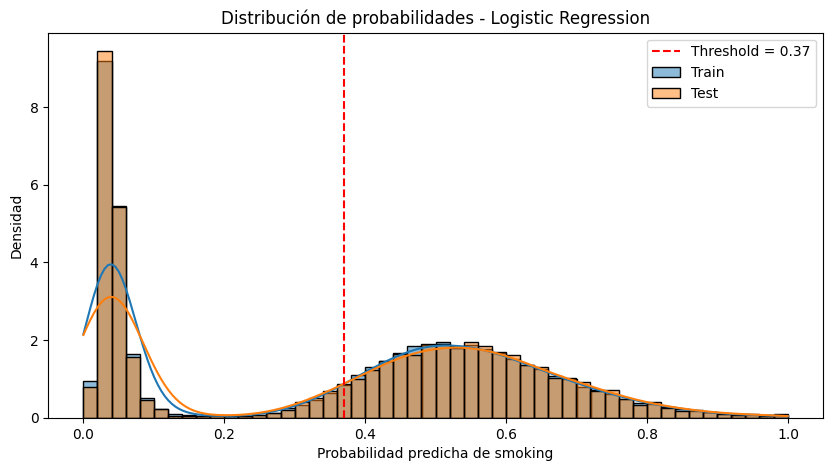

In [53]:
threshold_lr = 0.37

plt.figure(figsize=(10,5))

sns.histplot(
    y_proba_lr_train,
    bins=50,
    stat='density',
    kde=True,
    alpha=0.5,
    label='Train'
)

sns.histplot(
    y_proba_lr_test,
    bins=50,
    stat='density',
    kde=True,
    alpha=0.5,
    label='Test'
)

plt.axvline(
    threshold_lr,
    color='red',
    linestyle='--',
    label=f'Threshold = {threshold_lr}'
)

plt.title('Distribución de probabilidades - Logistic Regression')
plt.xlabel('Probabilidad predicha de smoking')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Aplicar Umbral

In [54]:
y_pred_lr_threshold = (
    y_proba_lr_test >= threshold_lr
).astype(int)

# Reporte

In [55]:
print(
    classification_report(
        y_test,
        y_pred_lr_threshold
    )
)

              precision    recall  f1-score   support

           0       0.93      0.60      0.73      6334
           1       0.57      0.92      0.71      3666

    accuracy                           0.72     10000
   macro avg       0.75      0.76      0.72     10000
weighted avg       0.80      0.72      0.72     10000



# XGBOOST - Probabilidades

In [56]:
y_proba_xgb_train = xgb.predict_proba(X_train)[:,1]
y_proba_xgb_test  = xgb.predict_proba(X_test)[:,1]

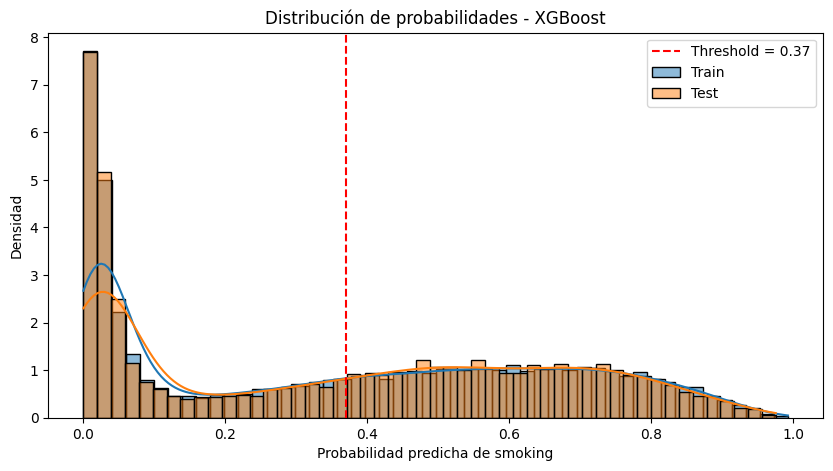

In [57]:
threshold_xgb = 0.37

plt.figure(figsize=(10,5))

sns.histplot(
    y_proba_xgb_train,
    bins=50,
    stat='density',
    kde=True,
    alpha=0.5,
    label='Train'
)

sns.histplot(
    y_proba_xgb_test,
    bins=50,
    stat='density',
    kde=True,
    alpha=0.5,
    label='Test'
)

plt.axvline(
    threshold_xgb,
    color='red',
    linestyle='--',
    label=f'Threshold = {threshold_xgb}'
)

plt.title('Distribución de probabilidades - XGBoost')
plt.xlabel('Probabilidad predicha de smoking')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Aplicar Umbral

In [58]:
y_pred_xgb_threshold = (
    y_proba_xgb_test >= threshold_xgb
).astype(int)

# Reporte

In [59]:
print(
    classification_report(
        y_test,
        y_pred_xgb_threshold
    )
)

              precision    recall  f1-score   support

           0       0.89      0.69      0.78      6334
           1       0.61      0.86      0.72      3666

    accuracy                           0.75     10000
   macro avg       0.75      0.77      0.75     10000
weighted avg       0.79      0.75      0.76     10000



# Resultado definitivo luego de los experimentos de umbral

| Ranking | Modelo              | F1 Score Test |
| ------- | ------------------- | ------------- |
| 🥇 1    | Random Forest       | 0.73          |
| 🥈 2    | XGBoost             | 0.72          |
| 🥉 3    | Logistic Regression | 0.71          |

## Conclusiones finales del proceso de entrenamiento y optimización

Durante el desarrollo del TP2 se priorizó la métrica objetivo definida para el trabajo, correspondiente al F1 Score, evaluando diferentes algoritmos y configuraciones con el objetivo de maximizar el desempeño sobre el conjunto de prueba.

Posteriormente, aprovechando el tiempo adicional disponible previo a la defensa y corrección final del trabajo y tomando como referencia los conceptos trabajados durante las clases prácticas, se realizaron experimentos complementarios sobre modelos probabilísticos utilizando umbrales de clasificación alternativos al valor estándar de 0.50. Como referencia inicial se utilizó la distribución observada durante la etapa de Discovery, donde aproximadamente el 37% de las observaciones correspondían a fumadores y el 63% a no fumadores.

Estos experimentos permitieron mejorar el equilibrio entre precisión y recall en Logistic Regression y XGBoost, obteniendo resultados más cercanos a los alcanzados por Random Forest, aunque sin superarlo en la métrica objetivo del trabajo.

Adicionalmente, al observar el fuerte sobreajuste (Overfitting) presentado por Random Forest, se realizaron pruebas utilizando hiperparámetros más conservadores similares a los trabajados durante las clases prácticas, incrementando restricciones como `n_estimators=300`, `min_samples_split=30` y `min_samples_leaf=100`. Si bien estas configuraciones lograron reducir considerablemente el sobreajuste (Overfitting) observado entre entrenamiento y prueba, también produjeron una disminución apreciable del F1 Score sobre el conjunto de test, motivo por el cual se decidió no adoptarlas como configuración final.

De manera similar, se realizaron experimentos adicionales sobre XGBoost incorporando configuraciones e ideas trabajadas durante las clases prácticas y explorando distintas alternativas de ajuste. Sin embargo, nuevamente se observó que las configuraciones más conservadoras o regularizadas tendían a sacrificar desempeño sobre la métrica objetivo del trabajo, por lo que se decidió conservar las configuraciones originalmente seleccionadas durante el proceso de entrenamiento y optimización.

Considerando que el objetivo principal del TP2 consistía en maximizar el desempeño medido mediante F1 Score, se decidió finalmente conservar las configuraciones originales de los modelos y documentar explícitamente las limitaciones asociadas al sobreajuste (Overfitting) detectado, priorizando el cumplimiento del objetivo del trabajo por sobre la capacidad de generalización obtenida por las configuraciones alternativas evaluadas.

Como resultado final, Random Forest continuó siendo el modelo con mejor desempeño sobre el conjunto de prueba y fue seleccionado para la generación de predicciones y entrega del trabajo práctico.
